# 🏦 Loan Approval Prediction — Logistic Regression from Scratch
> **Pipeline:** Data Loading → EDA → Preprocessing → Logistic Regression with Gradient Descent → Evaluation
>
> **Target:** Predict whether a loan will be `Approved` or `Rejected`


## 1️⃣ Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


## 2️⃣ Load Dataset

In [2]:
df = pd.read_csv("loan_approval_dataset.csv")

# Strip whitespace from column names
df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
df.head()


Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [4]:
df.describe()


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## 3️⃣ Exploratory Data Analysis (EDA)

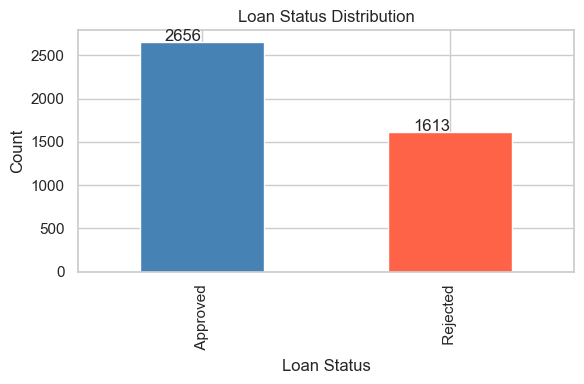

loan_status
Approved    62.22%
Rejected    37.78%
Name: proportion, dtype: object


In [5]:
# Target distribution
ax = df["loan_status"].value_counts().plot(
    kind="bar", color=["steelblue", "tomato"],
    title="Loan Status Distribution", figsize=(6, 4)
)
ax.set_xlabel("Loan Status")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.1, p.get_height() + 10))
plt.tight_layout()
plt.show()

print(df["loan_status"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")


ValueError: The palette dictionary is missing keys: {' Approved', ' Rejected'}

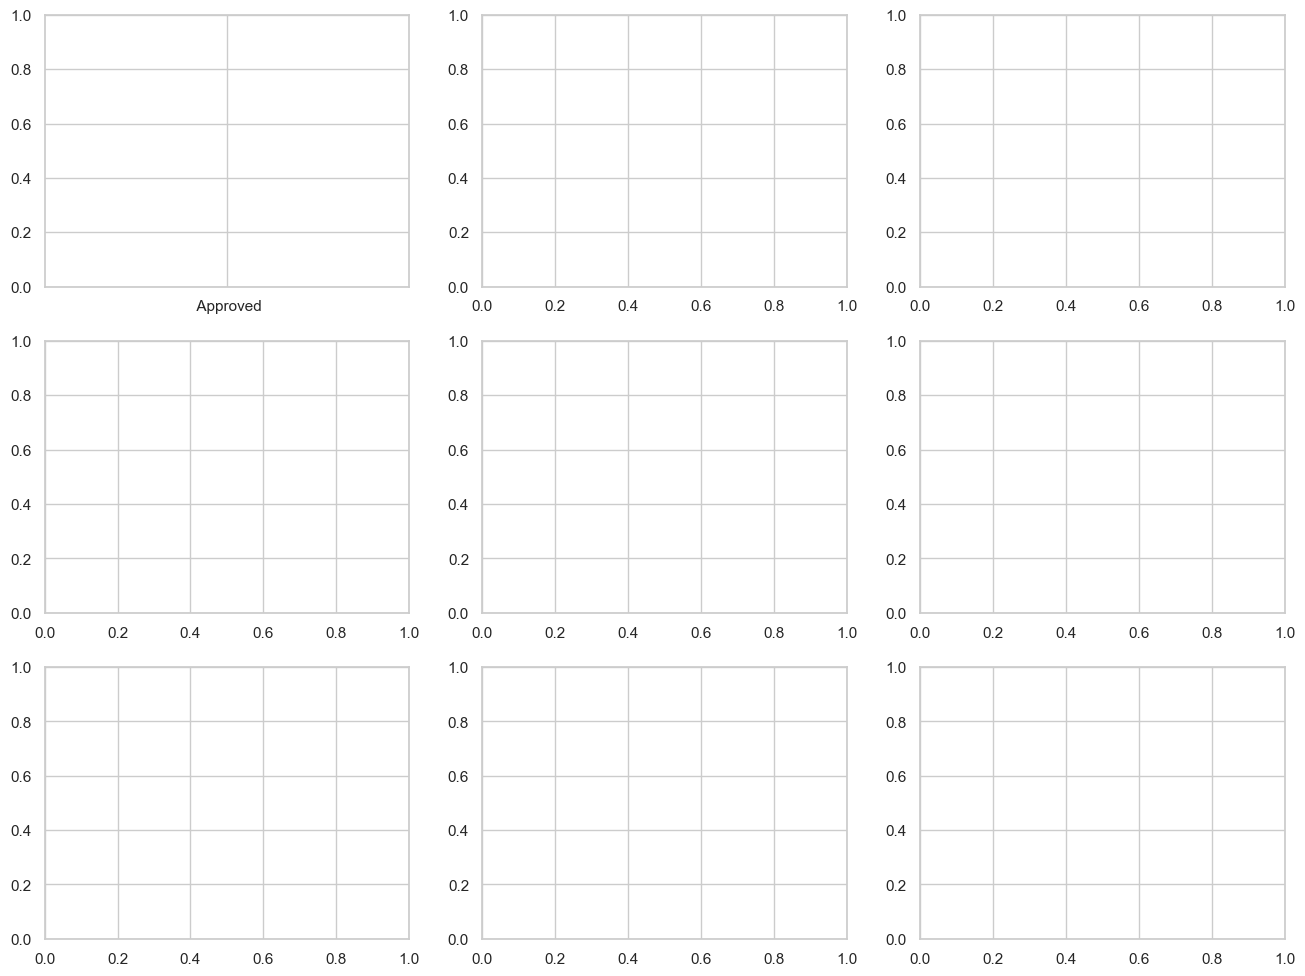

In [6]:
# Numerical features vs loan_status
num_cols = ["income_annum", "loan_amount", "cibil_score",
            "loan_term", "no_of_dependents",
            "residential_assets_value", "commercial_assets_value",
            "luxury_assets_value", "bank_asset_value"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="loan_status", y=col, ax=axes[i],
                palette={"Approved": "steelblue", "Rejected": "tomato"})
    axes[i].set_title(f"{col} vs Loan Status")
    axes[i].set_xlabel("")

plt.suptitle("Feature Distribution by Loan Status", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Categorical features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["education", "self_employed"]):
    ct = pd.crosstab(df[col], df["loan_status"], normalize="index") * 100
    ct.plot(kind="bar", ax=ax, color=["steelblue", "tomato"])
    ax.set_title(f"Approval Rate by {col}")
    ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="Status")

plt.tight_layout()
plt.show()


In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [ ]:
# CIBIL score is key — zoom in
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="cibil_score", hue="loan_status",
             bins=40, kde=True,
             palette={"Approved": "steelblue", "Rejected": "tomato"})
plt.title("CIBIL Score Distribution by Loan Status")
plt.tight_layout()
plt.show()


## 4️⃣ Data Preprocessing

In [7]:
# Strip whitespace from ALL string columns
str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

# Check nulls & duplicates
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Drop loan_id (not a feature)
df.drop(columns=["loan_id"], inplace=True)

print("\n✅ Cleaning done. Shape:", df.shape)
print("\nLoan status values:", df["loan_status"].unique())


Missing values:
 loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Duplicate rows: 0

✅ Cleaning done. Shape: (4269, 12)

Loan status values: ['Approved' 'Rejected']


In [8]:
# Encode target: Approved → 1, Rejected → 0
df["loan_status"] = df["loan_status"].str.strip().map({"Approved": 1, "Rejected": 0})

# Encode categorical features
df["education"]    = df["education"].str.strip().map({"Graduate": 1, "Not Graduate": 0})
df["self_employed"] = df["self_employed"].str.strip().map({"Yes": 1, "No": 0})

print("✅ Encoding done")
df.head(3)


✅ Encoding done


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0


In [9]:
# Feature / Target split
X = df.drop("loan_status", axis=1)
y = df["loan_status"].values

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")
print(f"Class balance (train) — 1: {y_train.mean():.2%}  0: {(1-y_train).mean():.2%}")


Train: (3415, 11)  |  Test: (854, 11)
Class balance (train) — 1: 62.23%  0: 37.77%


## 5️⃣ Logistic Regression — From Scratch

### 📐 Math

$$\sigma(z) = \frac{1}{1 + e^{-z}} \qquad \hat{y} = \sigma(Xw + b)$$

$$\mathcal{L} = -\frac{1}{n} \sum \left[ y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \right]$$

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{1}{n} X^T (\hat{y} - y) \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n} \sum (\hat{y} - y)$$

$$w \leftarrow w - \alpha \cdot \frac{\partial \mathcal{L}}{\partial w} \qquad b \leftarrow b - \alpha \cdot \frac{\partial \mathcal{L}}{\partial b}$$


In [10]:
class LogisticRegressionGD:
    """Logistic Regression trained via Batch Gradient Descent."""

    def __init__(self, learning_rate=0.1, n_iterations=1000,
                 threshold=0.5, verbose=True, log_every=100):
        self.lr           = learning_rate
        self.n_iterations = n_iterations
        self.threshold    = threshold
        self.verbose      = verbose
        self.log_every    = log_every

    def _sigmoid(self, z):
        # Numerically stable sigmoid
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))

    def _loss(self, y, y_hat):
        eps = 1e-15  # prevent log(0)
        y_hat = np.clip(y_hat, eps, 1 - eps)
        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights      = np.zeros(n_features)
        self.bias         = 0.0
        self.loss_history = []
        self.acc_history  = []

        for i in range(1, self.n_iterations + 1):
            z     = X @ self.weights + self.bias
            y_hat = self._sigmoid(z)

            # Gradients
            dw = (1 / n_samples) * (X.T @ (y_hat - y))
            db = (1 / n_samples) * np.sum(y_hat - y)

            # Update
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            # Track metrics
            loss = self._loss(y, y_hat)
            acc  = accuracy_score(y, (y_hat >= self.threshold).astype(int))
            self.loss_history.append(loss)
            self.acc_history.append(acc)

            if self.verbose and i % self.log_every == 0:
                print(f"Iter {i:5d} | Loss: {loss:.4f} | Accuracy: {acc:.4f}")

        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X):
        return (self.predict_proba(X) >= self.threshold).astype(int)


print("✅ LogisticRegressionGD class defined")


✅ LogisticRegressionGD class defined


In [11]:
model = LogisticRegressionGD(
    learning_rate=0.1,
    n_iterations=1000,
    threshold=0.5,
    verbose=True,
    log_every=100
)
model.fit(X_train_sc, y_train)


Iter   100 | Loss: 0.3134 | Accuracy: 0.9224
Iter   200 | Loss: 0.2697 | Accuracy: 0.9186
Iter   300 | Loss: 0.2534 | Accuracy: 0.9192
Iter   400 | Loss: 0.2450 | Accuracy: 0.9183
Iter   500 | Loss: 0.2399 | Accuracy: 0.9183
Iter   600 | Loss: 0.2366 | Accuracy: 0.9177
Iter   700 | Loss: 0.2343 | Accuracy: 0.9171
Iter   800 | Loss: 0.2326 | Accuracy: 0.9174
Iter   900 | Loss: 0.2313 | Accuracy: 0.9183
Iter  1000 | Loss: 0.2303 | Accuracy: 0.9174


## 6️⃣ Training Curves

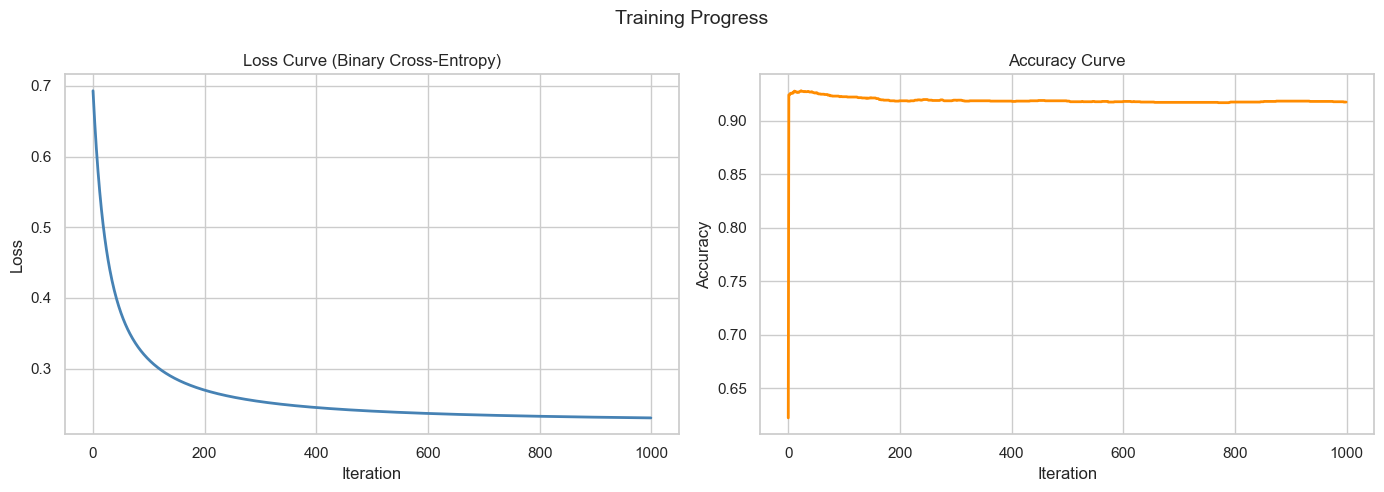

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(model.loss_history, color="steelblue", linewidth=2)
ax1.set_title("Loss Curve (Binary Cross-Entropy)")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss")

ax2.plot(model.acc_history, color="darkorange", linewidth=2)
ax2.set_title("Accuracy Curve")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Accuracy")

plt.suptitle("Training Progress", fontsize=14)
plt.tight_layout()
plt.show()


## 7️⃣ Model Evaluation

In [13]:
y_pred       = model.predict(X_test_sc)
y_pred_proba = model.predict_proba(X_test_sc)

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_proba)

print("=" * 45)
print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ROC-AUC  : {auc:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Rejected", "Approved"]))


  Accuracy : 0.9157  (91.57%)
  ROC-AUC  : 0.9732

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.91      0.87      0.89       323
    Approved       0.92      0.95      0.93       531

    accuracy                           0.92       854
   macro avg       0.91      0.91      0.91       854
weighted avg       0.92      0.92      0.92       854



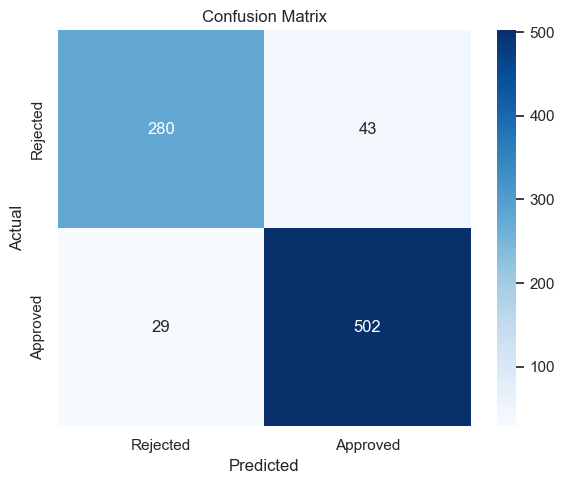

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


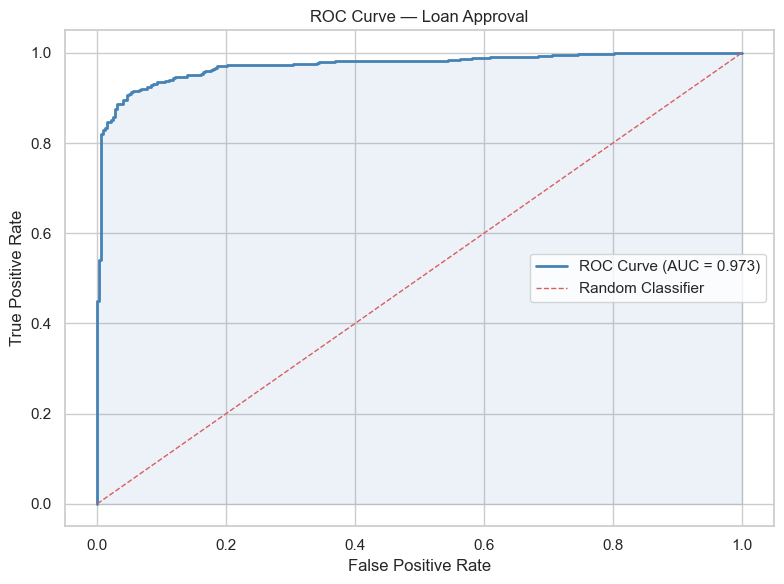

In [15]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="steelblue", linewidth=2,
         label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "r--", linewidth=1, label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.1, color="steelblue")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Loan Approval")
plt.legend()
plt.tight_layout()
plt.show()


## 8️⃣ Feature Importance (by |weight|)

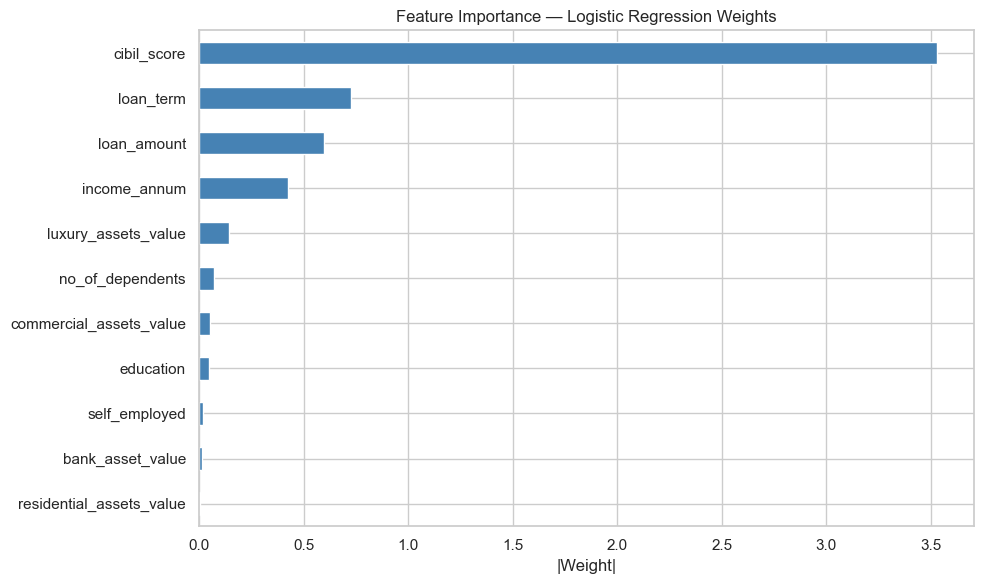


Top features:
cibil_score            3.530912
loan_term              0.724914
loan_amount            0.597946
income_annum           0.425832
luxury_assets_value    0.144431
dtype: float64


In [16]:
importance = pd.Series(np.abs(model.weights), index=X_train.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance.plot(kind="barh", color="steelblue")
plt.title("Feature Importance — Logistic Regression Weights")
plt.xlabel("|Weight|")
plt.tight_layout()
plt.show()

print("\nTop features:")
print(importance.sort_values(ascending=False).head(5))


## 9️⃣ Probability Distribution

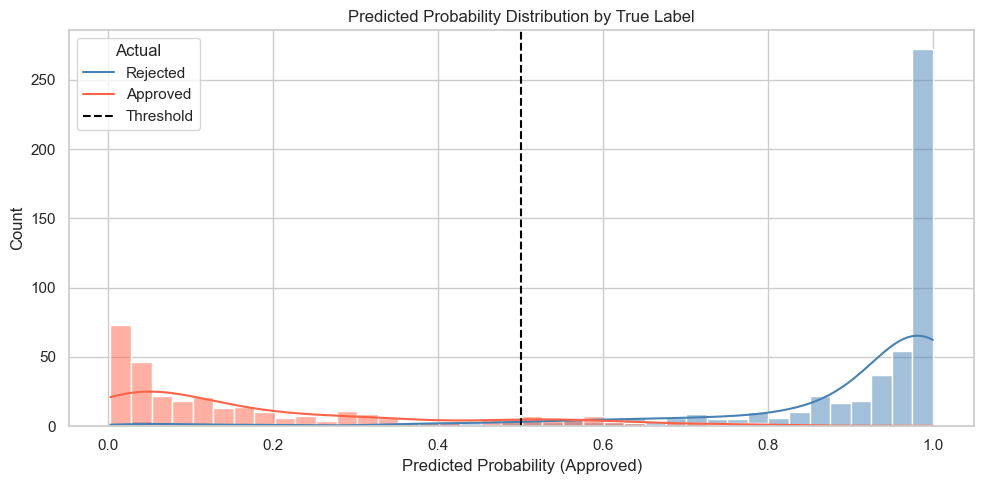

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(
    x=y_pred_proba,
    hue=y_test,
    bins=40,
    kde=True,
    palette={1: "steelblue", 0: "tomato"}
)
plt.axvline(0.5, color="black", linestyle="--", label="Threshold = 0.5")
plt.title("Predicted Probability Distribution by True Label")
plt.xlabel("Predicted Probability (Approved)")
plt.legend(title="Actual", labels=["Rejected", "Approved", "Threshold"])
plt.tight_layout()
plt.show()


## 🔟 Learning Rate Comparison

lr=0.001  →  Accuracy: 0.9426  |  AUC: 0.9735
lr=0.010  →  Accuracy: 0.9356  |  AUC: 0.9736
lr=0.100  →  Accuracy: 0.9157  |  AUC: 0.9732
lr=0.500  →  Accuracy: 0.9133  |  AUC: 0.9726


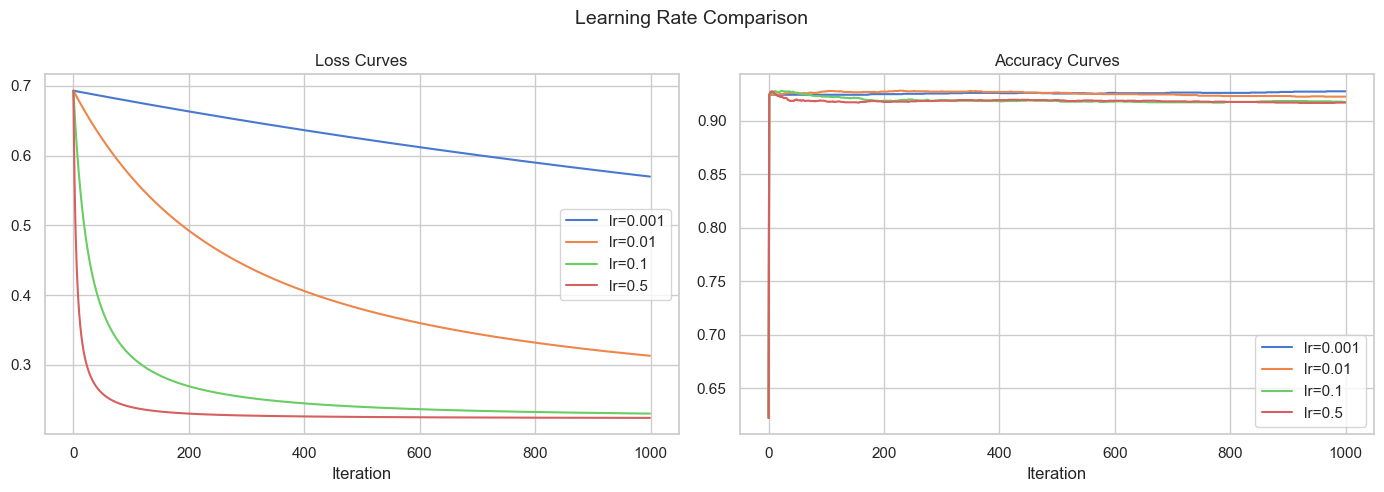

In [18]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
results = {}

for lr in learning_rates:
    m = LogisticRegressionGD(learning_rate=lr, n_iterations=1000, verbose=False)
    m.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_sc))
    auc = roc_auc_score(y_test, m.predict_proba(X_test_sc))
    results[lr] = {"model": m, "acc": acc, "auc": auc}
    print(f"lr={lr:.3f}  →  Accuracy: {acc:.4f}  |  AUC: {auc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for lr, res in results.items():
    ax1.plot(res["model"].loss_history, label=f"lr={lr}")
    ax2.plot(res["model"].acc_history,  label=f"lr={lr}")

ax1.set_title("Loss Curves")
ax1.set_xlabel("Iteration")
ax1.legend()

ax2.set_title("Accuracy Curves")
ax2.set_xlabel("Iteration")
ax2.legend()

plt.suptitle("Learning Rate Comparison", fontsize=14)
plt.tight_layout()
plt.show()


---
## ✅ Summary

| Step | Details |
|------|---------|
| **Dataset** | 4,269 loan applications with financial & personal features |
| **Target** | `loan_status` → Approved (1) / Rejected (0) |
| **EDA** | Box plots, bar charts, correlation heatmap, CIBIL analysis |
| **Cleaning** | Strip whitespace, drop duplicates & loan_id |
| **Encoding** | Binary encoding for education, self_employed, loan_status |
| **Scaling** | StandardScaler on all features |
| **Model** | Logistic Regression via **Batch Gradient Descent** from scratch |
| **Key Math** | Sigmoid + Binary Cross-Entropy + Gradient updates |
| **Evaluation** | Accuracy, ROC-AUC, Confusion Matrix, Classification Report |
| **Top Feature** | `cibil_score` — strongest predictor of loan approval |
